<a href="https://colab.research.google.com/github/anaag16123/INTELIGENCIA_ARTIFICIAL/blob/main/SEMANA_6/challenge/01_data_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [8]:
# Crear las carpetas internas en la sesión activa de Colab
!mkdir -p data/raw data/processed artifacts reports

In [9]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Directorios basados en la ruta actual
PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

# Crear directorios si no existen automáticamente
for directory in (RAW_DATA_DIR, PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [10]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

# Cargar el archivo en un DataFrame
df = pd.read_csv(DATA_PATH)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [13]:
# TODO 2: Profiling de calidad
print("Forma del dataset:", df.shape)
print("\nInformación del DataFrame:")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())
print("\nDistribución del target:")
print(df["target"].value_counts(normalize=True))

Forma del dataset: (178, 14)

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline

**Conclusión de calidad:**

> Describe brevemente qué encontraste y qué decisión tomaste.

Se cargaron exitosamente 178 registros y 14 columnas numéricas. No se encontraron valores nulos ni filas duplicadas en el conjunto de datos. La variable objetivo target cuenta con 3 clases representativas (~33%, ~39% y ~27%). Se procede al split estratificado sin requerir limpieza adicional.

## 2. Split train/test

In [14]:
# TODO 3: Crear el split estratificado (80/20)
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["target"]
)

assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (142, 14)
Test shape: (36, 14)


In [15]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

/tmp/ipykernel_1492/4251973817.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="target", ax=axes[0], palette="Set2")
/tmp/ipykernel_1492/4251973817.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="target", y="alcohol", ax=axes[1], palette="Set2")
/tmp/ipykernel_1492/4251973817.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="target", y="flavanoids", ax=axes[2], palette="Set2")


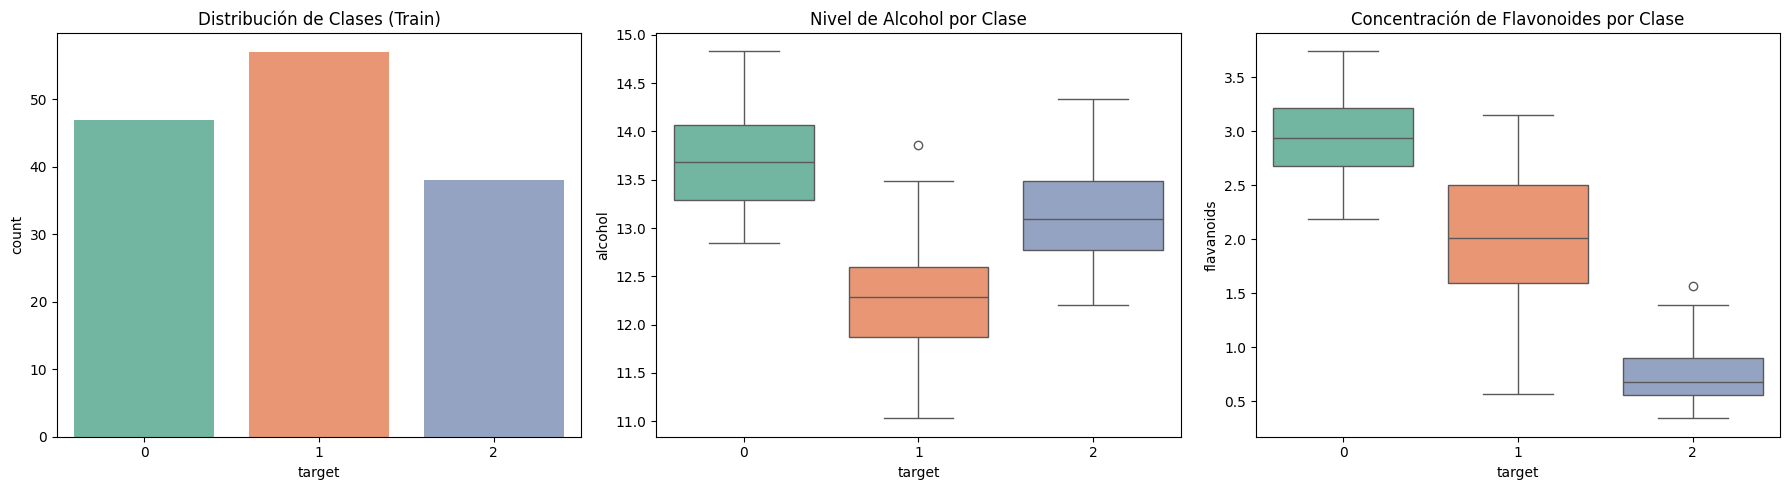

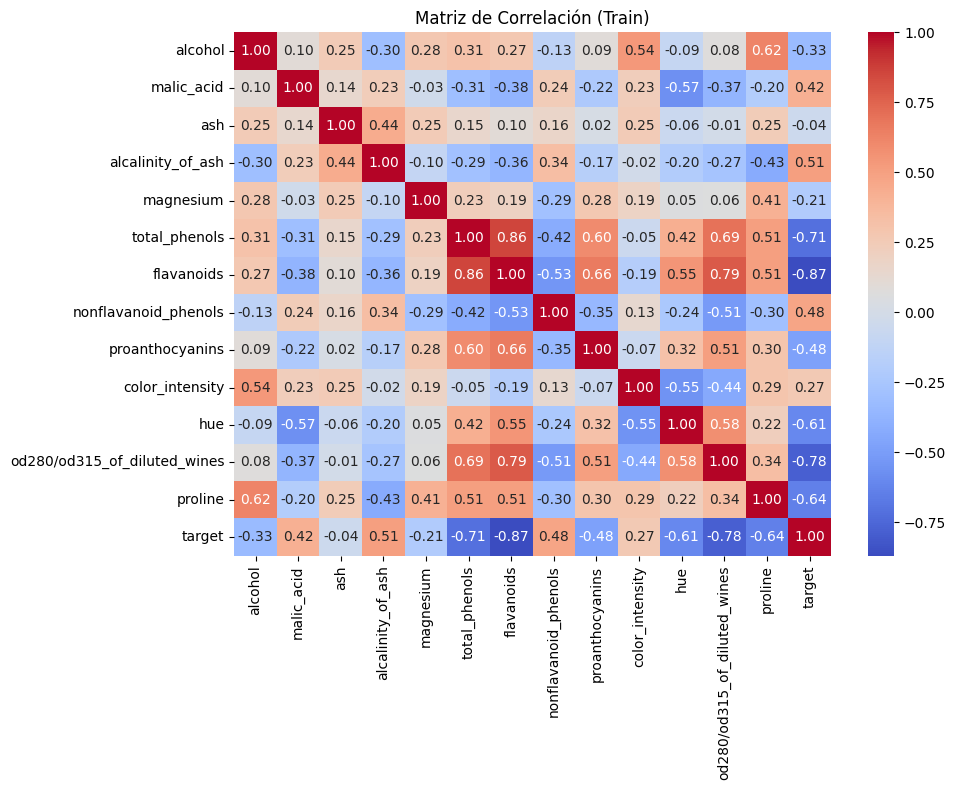

In [16]:
# TODO 4: Tres visualizaciones usando unicamente train_df
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de clases
sns.countplot(data=train_df, x="target", ax=axes[0], palette="Set2")
axes[0].set_title("Distribución de Clases (Train)")

# 2. Boxplot de Alcohol por clase
sns.boxplot(data=train_df, x="target", y="alcohol", ax=axes[1], palette="Set2")
axes[1].set_title("Nivel de Alcohol por Clase")

# 3. Boxplot de Flavonoides por clase
sns.boxplot(data=train_df, x="target", y="flavanoids", ax=axes[2], palette="Set2")
axes[2].set_title("Concentración de Flavonoides por Clase")

plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación (Train)")
plt.tight_layout()
plt.show()

**Hallazgos:**

1. Separabilidad: Atributos como flavanoids y proline presentan diferencias claras entre las tres clases de vino.

2. Correlación alta: Existe una fuerte correlación lineal positiva entre flavanoids y total_phenols (> 0.80).

3. Heterogeneidad de escalas: Las variables manejan magnitudes muy variadas (proline maneja valores en miles mientras que nonflavanoid_phenols maneja decimales inferiores a 1), requiriendo escalado/estandarización previa antes de entrenar modelos de clasificación.

## 4. Persistencia de datos y contrato

In [17]:
# TODO 5: Guardar salidas y data_contract.json
train_df.reset_index(drop=True).to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.reset_index(drop=True).to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

feature_cols = [col for col in train_df.columns if col != "target"]

data_contract = {
    "target": "target",
    "features": feature_cols,
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "n_train_samples": len(train_df),
    "n_test_samples": len(test_df)
}

with open(ARTIFACTS_DIR / "data_contract.json", "w") as f:
    json.dump(data_contract, f, indent=4)

assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado exitosamente.")

Challenge 1 completado exitosamente.


In [18]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


## Checklist

- [Si] Cargué el CSV desde `data/raw`.
- [Si] Revisé calidad y distribución de la clase.
- [Si] Realicé un split estratificado.
- [Si] No exploré el conjunto de test.
- [Si] Guardé los tres artefactos requeridos.